# Лабораторная работа 3

## Сингулярное разложение и его приложения

Напомним, что сингулярным разложением (SVD, Singular value decomposition) матрицы $A$ размера $m\times n$ называется представление

$$A = U\Sigma V^T,$$

где $U$ — ортогональная матрица размера $m\times m$, $V$ — ортогональная матрица размера $n\times n$, $\Sigma = \mathrm{diag}(\sigma_1,\sigma_2,\sigma_3,\ldots)$ — диагональная матрица размера $m\times n$, в которой $\sigma_1\geqslant\sigma_2\geqslant\ldots\geqslant0$.

На самом деле требование, чтобы матрицы $U$ и $V$ были квадратными, избыточно. *Усечённым сингулярным разложением* мы будем называть разложение

$$A = U\Sigma V^T,$$

где $U$ и $V$ — матрицы с ортонормированными столбцами размеров $m\times k$ и $n \times k$ соответственно, $\Sigma$ — диагональная матрица размера $k\times k$, где $k = \min(m,n)$. Далее мы будем работать исключительно с усечённым разложением.

### Сжатие данных с помощью SVD = построение низкорангового приближения

Введём *норму Фробениуса* матрицы как

$$||A||_{frob} = \sqrt{\mathrm{tr}{A^TA}} = \sqrt{\sum\limits_{i,j}a^2_{i,j}}$$

Иными словами, это обычное евклидово расстояние на пространстве, которое получается, если все матрицы вытянуть в длинные векторы.

Зададимся вопросом: как найти матрицу $A_{r}$ ранга $r$, наименее отличающуюся от $A$ по норме Фробениуса (то есть для которой норма разности $||A - A_{r}||_{frob}$ минимальна). Оказывается, это можно сделать с помощью сингулярного разложения:

**Теорема.** Пусть $\Sigma_{r}$ — это матрица, полученная из $\Sigma$ заменой диагональных элементов $\sigma_{i}$ ($i > r$) нулями, тогда $A_{r} = U\Sigma_{r}V^T$.

Это можно переписать и в более экономичном виде. Если

$$A = \underbrace{
\begin{pmatrix}
u_{11} & \ldots & u_{1k}\\
\vdots & & \vdots\\
u_{m1} & \ldots & u_{mk}
\end{pmatrix}}_{=U}\cdot\underbrace{{
\begin{pmatrix}
\sigma_{1} & &\\
 & \sigma_{2} & \\
 & & \ddots
\end{pmatrix}}
}_{=\Sigma}\cdot \underbrace{
\begin{pmatrix}
v_{11} & \ldots & v_{n1}\\
\vdots & & \vdots\\
v_{1k} & \ldots & v_{nk}
\end{pmatrix}}_{=V^T}$$

то

$$A_{r} = \underbrace{
\begin{pmatrix}
u_{11} & \ldots & u_{1r}\\
\vdots & & \vdots\\
u_{m1} & \ldots & u_{mr}
\end{pmatrix}}_{=U_r}\cdot\underbrace{{
\begin{pmatrix}
\sigma_{1} & &\\
 & \ddots & \\
 & & \sigma_{r}
\end{pmatrix}}
}_{=\Sigma_r}\cdot \underbrace{
\begin{pmatrix}
v_{11} & \ldots & v_{n1}\\
\vdots & & \vdots\\
v_{1r} & \ldots & v_{nr}
\end{pmatrix}}_{=V^T_r}$$

При этом

$$||A - A_{r}||_{frob} = \sqrt{\sum\limits_{i\geqslant r+1} \sigma_{i}^2}$$

Если сингулярные значения матрицы падают достаточно быстро (а в реальных задачах часто бывает именно так), то норма разности будет малой при сравнительно небольшом значении $r$.

На хранение исходной матрицы нам требовалось $m\times n$ памяти. Теперь же, если мы будем хранить отдельно $U_r$, $V_r$ и диагональные элементы $\Sigma_r$, затраты памяти составят $mr + nr + r = r(m + n + 1)$.

**Разложение на компоненты ранга 1**

Обозначим через $u_1,\ldots, u_k$ столбцы матрицы $U$, а через $v_1, \ldots, v_k$ столбцы матрицы $V$. Тогда имеет место равенство

$$A = u_1\sigma_{1}v_1^T + u_2\sigma_{2}v_2^T + u_3\sigma_{3}v_3^T + \ldots$$

Матрицу $u_k\sigma_{k}v_k^T = \sigma_{k}u_kv_k^T$ мы будем называть $k$-й компонентой ранга 1 матрицы $A$. Отметим, что слагаемые в этой сумме ортогональны относительно скалярного произведения $(X, Y) = \mathrm{tr}(X^TY)$ (порождающего норму Фробениуса).

Как нетрудно заметить,

$$A_{r} = \sigma_{1}u_1v_1^T + \sigma_{2}u_2v_2^T + \ldots + \sigma_{r}u_rv_r^T$$

**Технические детали (SVD в Питоне)**

Есть несколько способов сделать в Питоне сингулярное разложение; мы пока предлагаем Вам использовать

`import scipy.linalg as sla`

`U, S, Vt = sla.svd(X, full_matrices=False)`

Для ознакомления с особенностями этой функции рекомендуем обратиться к [документации](https://docs.scipy.org/doc/scipy/reference/generated/scipy.linalg.svd.html) (в частности, обратите внимание на то, какие именно объекты она возвращает).

### Правила оформления графиков

При работе с данными часто неудобно делать какие-то выводы, если смотреть на таблицу и числа в частности, поэтому важно уметь визуализировать данные.

У matplotlib, конечно же, есть [документация](https://matplotlib.org/users/index.html) с большим количеством [примеров](https://matplotlib.org/examples/), но для начала достаточно знать про несколько основных типов графиков:
- plot — обычный поточечный график, которым можно изображать кривые или отдельные точки;
- hist — гистограмма, показывающая распределение некоторой величины;
- scatter — график, показывающий взаимосвязь двух величин;
- bar — столбцовый график, показывающий взаимосвязь количественной величины от категориальной.

Ещё одна билиотека для визуализации: [seaborn](https://jakevdp.github.io/PythonDataScienceHandbook/04.14-visualization-with-seaborn.html). Это настройка над matplotlib, иногда удобнее и красивее делать визуализации через неё.

Не забывайте про базовые принципы построения приличных графиков:
- оси должны быть подписаны, причём не слишком мелко;
- у графика должно быть название;
- если изображено несколько графиков, то необходима поясняющая легенда;
- для точек из разных выборок, необходимо использовать разные цвета;
- все линии на графиках должны быть чётко видны (нет похожих цветов или цветов, сливающихся с фоном);
- размер графика должен быть таким, чтобы по нему несложно было сделать необходимые выводы о данных;
- если отображена величина, имеющая очевидный диапазон значений (например, проценты могут быть от 0 до 100), то желательно масштабировать ось на весь диапазон значений (исключением является случай, когда вам необходимо показать малое отличие, которое незаметно в таких масштабах).

Помните, что проверяющий имеет право снизить оценку за неопрятные графики.

### Оценивание

Обратите внимание, что в каждом разделе есть задания на написания кода и есть вопросы. Вопросы дополняют задачи и направлены на то, чтобы проинтерпретировать или обосновать происходящее. Код без интерпретации не имеет смысла, поэтому отвечать на вопросы обязательно — за отсутствие ответов мы будем снижать баллы за задачи. Если Вы ответите на вопросы, но не напишете корректный код к соответствующим оцениваемым задачам, то в подавляющем большинстве случаев баллы за такое выставлены не будут.

### Формат сдачи
Задания сдаются через систему Anytask. Инвайт можно найти на странице курса. Присылать необходимо ноутбук с выполненным заданием. Сам ноутбук называйте в формате homework-practice-03-linregr-Username.ipynb, где Username — Ваша фамилия.

### Задание 1. Сжатие данных с помощью SVD

Загрузите выложенную на странице курса фотографию.

In [ ]:
import numpy as np
from skimage.io import imread

img = imread(r'chain_small.jpg')
img = img.mean(axis=2) # это матрица из интенсивностей серого цвета; её уже можно подвергать SVD

Нарисуйте картинку:

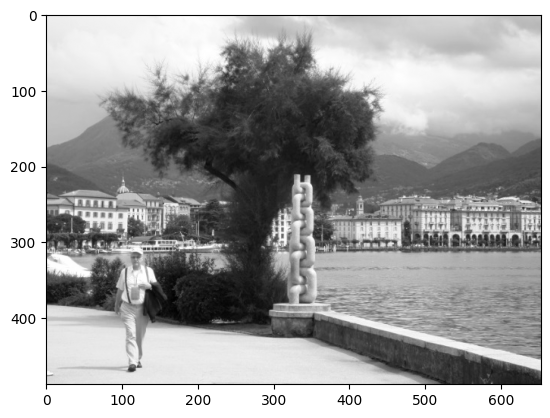

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

imgplot = plt.imshow(img, cmap='gray')

Постройте сингулярное разложение этой матрицы.

In [ ]:
from numpy.linalg import svd

U, S, VT = svd(img, full_matrices=False)

**1. [0.1 балла]** Нарисуйте график диагональных элементов матрицы $\Sigma$:

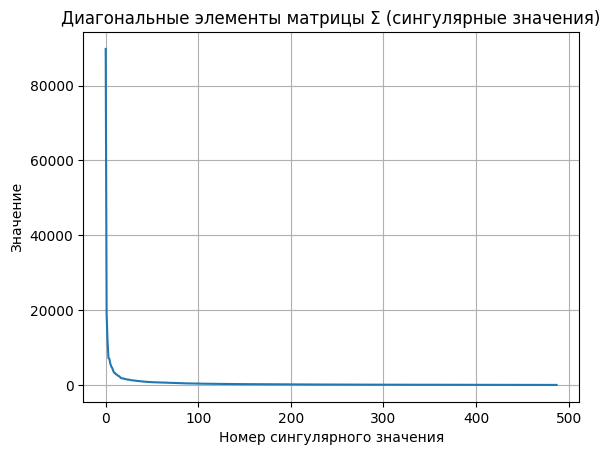

In [ ]:
plt.plot(S)
plt.title('Диагональные элементы матрицы Σ (сингулярные значения)')
plt.xlabel('Номер сингулярного значения')
plt.ylabel('Значение')
plt.grid(True)
plt.show()

Кажется, что они убывают достаточно быстро и есть надежда, что первые несколько компонент дадут картинку, близкую к исходной.

**Важно:** при визуализации различных компонент в этом задании используйте только матричные операции. В частности, избегайте циклов, функций `map` и `reduce`, а также специальных функций, находящих суммы компонент.

**2. [0.1 балла]** Визуализуйте первую компоненту ранга 1. Ожидали ли Вы увидеть именно это? Поясните.

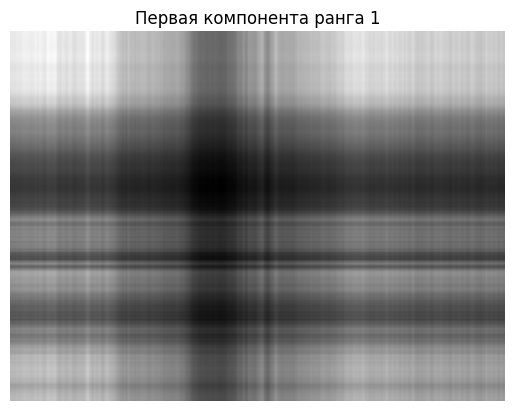

In [ ]:

rank_1_approx = S[0] * np.outer(U[:, 0], VT[0, :])
import matplotlib.pyplot as plt
plt.imshow(rank_1_approx, cmap='gray')
plt.title('Первая компонента ранга 1')
plt.axis('off')
plt.show()

При использовании первой компоненты мы видим размытое приближение изображения. Оно содержит глобальные характеристики, но теряет детали, так как компонента ранга 1 захватывает наиболее важное направление дисперсии в изображении. Поэтому такой результат был ожидаемым

**3. [0.5 балла]** Визуализуйте суммы компонент ранга 1 с первой по двадцатую, с первой по пятидесятую, с двадцатой по сотую, с двадцатой по последнюю. Сделайте выводы.

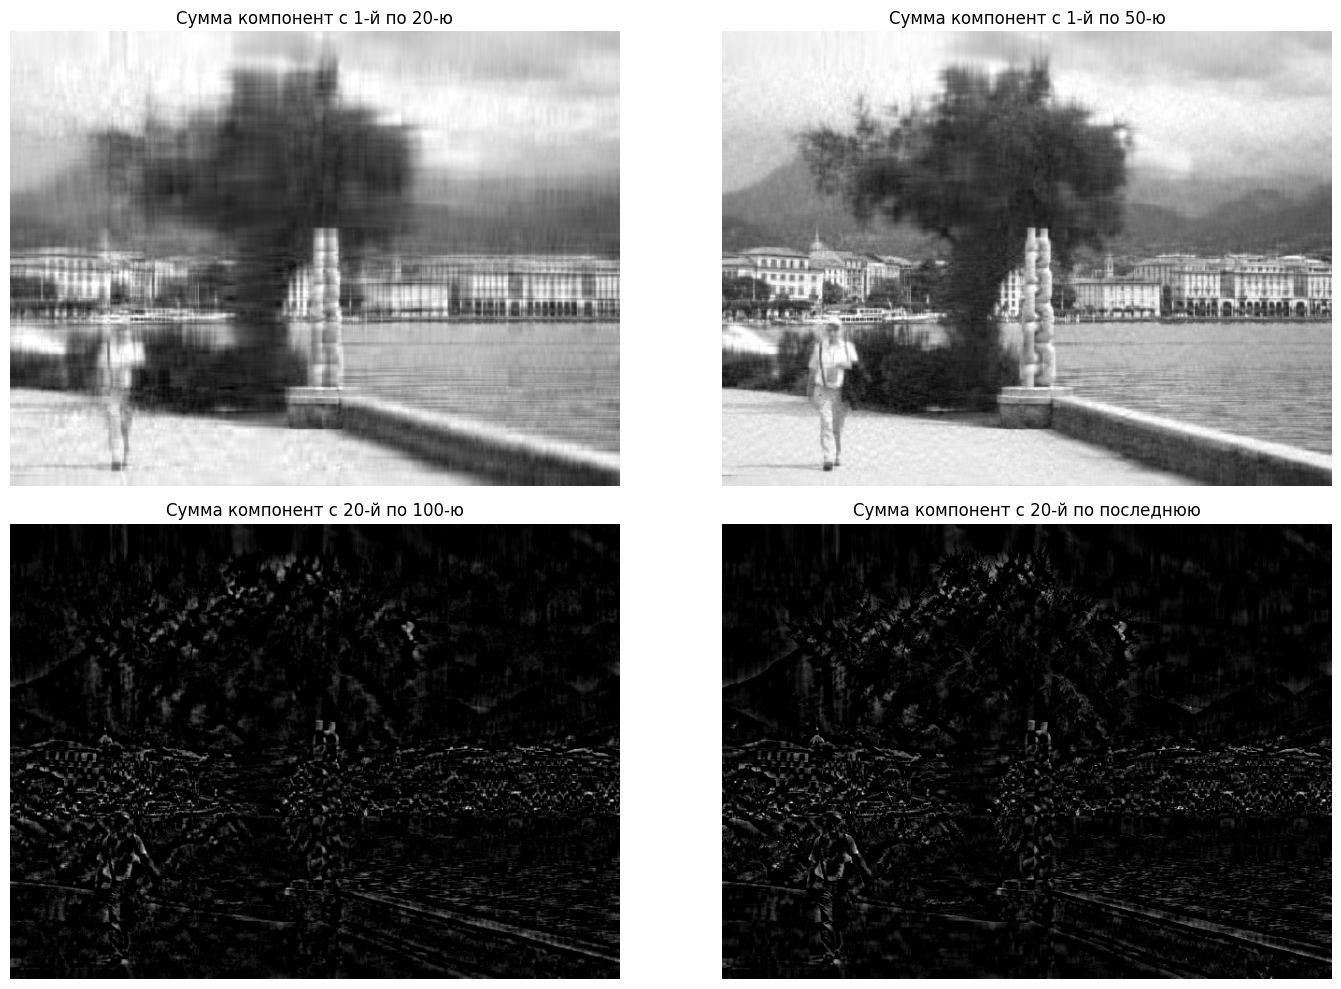

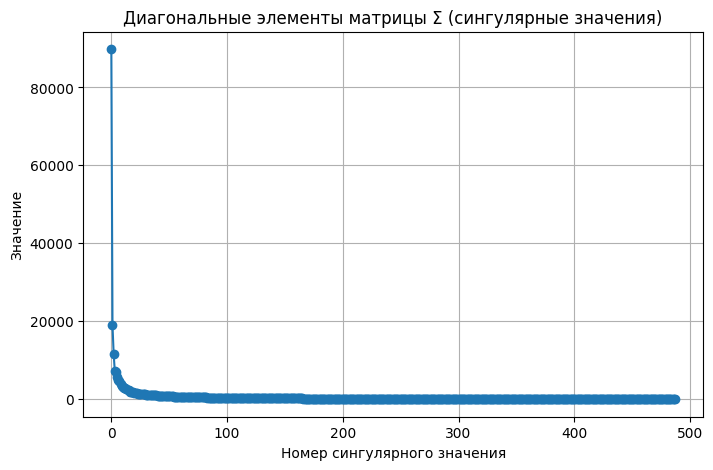

In [ ]:
def compute_rank_sum(U, S, VT, start_idx, end_idx):
    rank_sum = np.zeros_like(img)
    for i in range(start_idx, min(end_idx, len(S))):
        rank_sum += S[i] * np.outer(U[:, i], VT[i, :])
    rank_sum = np.clip(rank_sum, 0, 255)
    return rank_sum
ranges = [
    (1, 20, "Сумма компонент с 1-й по 20-ю"),
    (1, 50, "Сумма компонент с 1-й по 50-ю"),
    (20, 100, "Сумма компонент с 20-й по 100-ю"),
    (20, len(S), "Сумма компонент с 20-й по последнюю")
]

plt.figure(figsize=(15, 10))
for idx, (start, end, title) in enumerate (ranges, 1):
    rank_sum = compute_rank_sum(U, S, VT, start-1, end)
    plt.subplot(2, 2, idx)
    plt.imshow(rank_sum, cmap='gray')
    plt.title(title)
    plt.axis('off')
plt.tight_layout()
plt.show()
plt.figure(figsize=(8, 5))
plt.plot(S, marker='o')
plt.title('Диагональные элементы матрицы Σ (сингулярные значения)')
plt.xlabel('Номер сингулярного значения')
plt.ylabel('Значение')
plt.grid(True)
plt.show()

Разница в графиках сумм компонент ранга 1 отражает вклад различных диапазонов сингулярных значений. Сумма с 1-й по 20-ю дает размытое изображение с крупными структурами, с 1-й по 50-ю добавляет деталей, делая картинку четче. Диапазон с 20-й по 100-ю исключает основные компоненты, что делает изображение неузнаваемым. Сумма с 20-й по последнюю немного улучшает детали, но без первых компонент остается неинформативной. Первые компоненты важны для структуры, а последующие лишь уточняют детали, что видно по возрастающей четкости при увеличении числа компонент.

**4. [0.35 балла]** Как Вам кажется, какие компоненты нужно взять для достаточно хорошего восстановления исходного изображения? Аргументируйте свой ответ. Не забудьте визуализировать сумму выбранных компонент.

*Комментарий: для получения полного балла за это задания постарайтесь привести более убедительный аргумент, нежели Ваши субъективные впечатления от сравнения полученного изображения с исходным.*

Сингулярные значения убывают достаточно быстро: первые 20 компонент восстанавливают грубую структуру изображения, но содержат мало деталей. При использовании первых 50 компонент — изображение уже близко к оригиналу, однако всё ещё можно заметить лёгкую потерю мелких деталей и размытость.

Использование первых 100 компонент позволяет достичь визуального качества, практически не отличимого от оригинала. Это подтверждается тем, что последующие сингулярные значения становятся очень малыми.

Таким образом, 100 компонент достаточно для качественного восстановления, а дальнейшее увеличение числа компонент даёт минимальный прирост точности при значительном увеличении вычислительных затрат и размера данных.



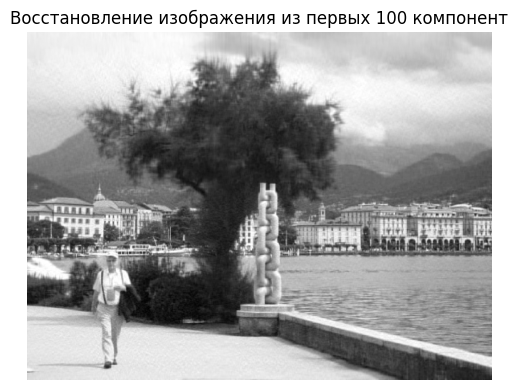

In [ ]:
def compute_rank_sum(U, S, VT, start_idx, end_idx):
    rank_sum = np.zeros_like(img, dtype=float)
    for i in range(start_idx, min(end_idx, len(S))):
        rank_sum += S[i] * np.outer(U[:, i], VT[i, :])
    rank_sum = np.clip(rank_sum, 0, 255)
    return rank_sum.astype(np.uint8)

chosen_rank_sum = compute_rank_sum(U, S, VT, 0, 100)

plt.figure(figsize=(6, 6))
plt.imshow(chosen_rank_sum, cmap='gray')
plt.title("Восстановление изображения из первых 100 компонент")
plt.axis('off')
plt.show()

**5. [0.15 балла]** Во сколько раз меньше памяти (теоретически) потребуется для хранения нового изображения по сравнению с исходным?

Если исходное изображение и SVD-приближение хранятся в формате float (4 байта на число), то при использовании $k$ компонент разложения память для хранения приближённого изображения составит $k(m + n + 1)$ чисел, тогда как исходное изображение требует $m \times n$ чисел. Теоретически объём памяти сокращается в $\frac{m \times n}{k(m + n + 1)}$ раз. Например, для изображения размером $512 \times 512$ и $k = 100$, приближённое представление потребует примерно в 2.56 раза меньше памяти, чем полное изображение при одинаковом типе данных


**6. [0.25 балла]** Подсчитайте, сколько в действительности места в памяти компьютера занимают исходная матрица и компоненты её сингулярного разложения. Согласуется ли этот результат с ответом предыдущего пункта? Сделайте выводы.

Для изображения размером 512×512 в формате float32 исходная матрица занимает 512×512×4 = 1 048 576 байт. При сингулярном разложении с использованием 100 компонент требуется хранить 512×100 элементов для U, 100 значений для S и 100×512 элементов для Vᵀ — всего 102 500 чисел, что составляет 102 500×4 = 410 000 байт (≈400 КБ). Отношение объёмов памяти составляет 1 048 576 / 410 000 ≈ 2.56, что совпадает с теоретическим расчётом по формуле $\frac{mn}{k(m+n+1)}$. Вроде на практике приближённое представление действительно требует в 2.56 раза меньше памяти, подтверждая теоретические выводы и демонстрируя эффективность SVD для сжатия изображений.


### Задание 2. Геометрия SVD. Визуализация данных с помощью SVD

**Геометрический смысл SVD**

Допустим, что у нас есть выборка $x_1,\ldots,x_m\in\mathbb{R}^n$. Запишем её в матрицу объекты-признаки

$$X = \begin{pmatrix}
x_{11} & \ldots & x_{1n}\\
\vdots & & \vdots\\
x_{m1} & \ldots & x_{mn}
\end{pmatrix}$$

(строки — объекты, столбцы — признаки) и сделаем SVD-разложение: $X = U\Sigma V^T$. Его можно интерпретировать следующим образом:

$$X = U\Sigma\cdot V^T,$$

где $U\Sigma$ — это матрица объекты-признаки для тех же объектов, но в новых признаках, полученных из исходных с помощью линейного преобразования $V$ (напоминаем, что умножение на матрицу справа соответствует преобразованию столбцов). Попробуем понять, чем замечательны эти признаки.

Рассмотрим матрицу $X^TX = V\Sigma^2V^T$. Легко видеть, что это матрица Грама системы столбцов матрицы $X$; иными словами, в ней записаны скалярные произведения векторов различных признаков. Из лекций вы знаете, что $\sigma_1^2$, квадрат первого сингулярного числа, это наибольшее собственное значение матрицы $X^TX$, а $v_1$, первый столбец матрицы $V$, — это соответствующий собственный вектор. Можно показать, что

$$\sigma_1 = \mathrm{max}_{w}\frac{|Xw|}{|w|} = \mathrm{max}_{|w| = 1}\left(|Xw|\right).$$

Попробуем осознать физический смысл этой штуки. Напомним, что строки матрицы $X$ — это координаты объектов $x_1,\ldots,x_m$ в пространстве признаков. Произведение $Xw$ — это вектор из значений на тех же самых объектах некоторого нового признака, являющегося линейной комбинацией исходных с коэффициентами $w_1,\ldots,w_n$:

$$Xw = w_1\begin{pmatrix} x_{11}\\ \ldots \\ x_{m1}
\end{pmatrix} + w_2\begin{pmatrix} x_{12}\\ \ldots \\ x_{m2}
\end{pmatrix} + \ldots + w_n\begin{pmatrix} x_{1n}\\ \ldots \\ x_{mn}
\end{pmatrix}$$

Соответственно, $|Xw|^2$ — это квадрат длины вектора, составленного из значений нового признака.

Таким образом, первому сингулярному значению $\sigma_1$ отвечает такой признак, у которого сумма квадратов значений максимальна, то есть признак, принимающий, условно говоря, самые большие значения.

Резюмируя, мы можем сказать, что сингулярное разложение делает следующее:
- находит новый признак (новое направление) вдоль которого "дисперсия"$^1$ максимальна;
- в ортогональной ему плоскости находит признак, вдоль которого "дисперсия" максимальна;
- и так далее.

---
$^1$ настоящая выборочная дисперсия с точностью до числового множителя была бы равна $|Xw - \overline{Xw}|^2$, где $\overline{Xw} = \frac1m\sum_{i=1}^m(Xw)_i$ — среднее значения признака.

**1. [1.25 балла]** Пусть $\sigma_1$ — старшее сингулярное число матрицы $X$ размера $m \times n$. Покажите, что верна цепочка равенств
$$\sigma_1 = \mathrm{max}_{w}\frac{|Xw|}{|w|} = \mathrm{max}_{|w| = 1}~|Xw| = \mathrm{max}_{|u|=|v| = 1}~|u^T Xv|.$$

**Подсказки:**
* при доказательстве равенства $\sigma_1 = \mathrm{max}_{w}\frac{|Xw|}{|w|}$ выразите вектор $w$ как $\alpha\cdot v$, где $|v|=1$, и рассмотрите описанное выражение
* при доказательстве равенства $\sigma_1 = \mathrm{max}_{|w| = 1}~|Xw|$ представьте $w$ в виде линейной комбинации ортонормированного базиса, состоящего из собственных векторов оператора $X^TX$, и внимательно посмотрите на произведение $wX^TXw$
* при доказательстве равенства $\sigma_1 = \mathrm{max}_{|u|=|v| = 1}~|u^T Xv|$ разложите матрицу $X$ в SVD-разложение, а векторы $u$ и $w$ представьте в виде линейной комбинации векторов, являющихся столбцами матриц $U$ и $V$.



$$
\|X\|_2 = \max_{w \ne 0} \frac{\|Xw\|}{\|w\|} = \sigma_1
$$

Это следует из того, что $\|X\|_2$ — максимальное растяжение, которое производит матрица $X$ на вектор $w$, и достигается на сингулярном векторе $v_1$, соответствующем $\sigma_1$. То есть, если $w = v_1$, где $V = [v_1, v_2, \dots]$ — правая ортонормированная матрица в SVD, то $\|Xw\| = \sigma_1$, и $\|w\| = 1$.


Для любого $w \ne 0$, можно переписать:

$$
\frac{\|Xw\|}{\|w\|} = \|X(\frac{w}{\|w\|})\|
$$

А значит, максимум по произвольным $w \ne 0$ эквивалентен максимуму по всем единичным векторам $w$:

$$
\max_{w \ne 0} \frac{\|Xw\|}{\|w\|} = \max_{\|w\| = 1} \|Xw\|
$$

$\max_{\|w\| = 1} \|Xw\| = \max_{\|u\| = \|v\| = 1} |u^T X v|$

Теперь юзаем SVD:

$$
X = U \Sigma V^T
$$

где $\Sigma = \text{diag}(\sigma_1, \dots, \sigma_r)$, $U$ и $V$ — ортонормированные.

Для любых $\|u\| = 1$, $\|v\| = 1$, имеем:

$$
|u^T X v| = |u^T U \Sigma V^T v| = |(U^T u)^T \Sigma (V^T v)|
$$

Пусть $a = U^T u$, $b = V^T v$. Тогда $a, b$ — единичные векторы (так как $U$ и $V$ — ортонормированные).

$$
|u^T X v| = |a^T \Sigma b| = \left| \sum_{i=1}^{r} \sigma_i a_i b_i \right| \leq \sigma_1 \sum |a_i b_i| \leq \sigma_1 \|a\| \cdot \|b\| = \sigma_1
$$

Максимум достигается при $a = b = e_1$ (то есть $u = u_1$, $v = v_1$), и тогда:

$$
|u^T X v| = \sigma_1
$$


$$
\max_{\|w\| = 1} \|Xw\| = \sigma_1 = \max_{\|u\| = \|v\| = 1} |u^T X v|
$$




╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ

**2. [0.75 балла]** Рассмотрим матрицу $A = (a_{ij})$ размера $n \times n$, такую что $a_{ij} = \sin i \cdot \cos j$, причём нумерация ведётся с нуля. Найдите $r = \text{rk}A$ (можете считать, что $n > 1$), а также разложение (Compact SVD) $A=U \Sigma V^T$, где $U$ и $V$ — матрицы с ортонормированными столбцами размера $n\times r$, а $\Sigma = \mathrm{diag}(\sigma_1,\ldots,\sigma_r)$ — диагональная матрица размера $r\times r$, в которой $\sigma_1\geqslant\ldots\geqslant\sigma_r > 0$.

столбец $u \in \mathbb{R}^{n}$: $u_i = \sin(i)$
строка $v^T \in \mathbb{R}^{n}$: $v_j = \cos(j)$

Тогда каждый элемент $a_{ij}$ матрицы можно представить как:

$$
a_{ij} = u_i \cdot v_j
$$

$$
A = u \cdot v^T
$$


$$
A = \begin{bmatrix} \sin(0) \\ \sin(1) \\ \vdots \\ \sin(n-1) \end{bmatrix}
\cdot
\begin{bmatrix} \cos(0) & \cos(1) & \cdots & \cos(n-1) \end{bmatrix}
$$

Ранг матрицы $A$ 1, тк она представима как произведение столбца на строку. **$\mathrm{rank}(A) = 1$**.



Матрицу ранга 1 можно разложить по формуле компактного сингулярного разложения:

$$
A = \sigma_1 \cdot u_1 \cdot v_1^T
$$
$u_1 \in \mathbb{R}^n$, $v_1 \in \mathbb{R}^n$ — ортонормированные векторы;
$\sigma_1 = \|u\| \cdot \|v\|$, так как:

  $$
  A = u v^T = (\|u\| \cdot \hat{u})(\|v\| \cdot \hat{v})^T = \sigma_1 \cdot \hat{u} \cdot \hat{v}^T
  $$


 $\Sigma = [\sigma_1]$, где $\sigma_1 = \|u\| \cdot \|v\|$
 $U = [\hat{u}] = \frac{u}{\|u\|}$,
 $V = [\hat{v}] = \frac{v}{\|v\|}$



╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ

**3. [0.5 балла]** Рассмотрим полное сингулярное разложение $A = U \Sigma V^T$ для матрицы размера $m \times n$, такой что $\text{rk}A=r$. Определим также линейное отображение $\mathcal{A} \colon \mathbb{R}^n \to \mathbb{R}^m$, которое действует умножением на матрицу $A$. Покажите, что $\text{Im}\mathcal{A} = \langle u_1, \ldots, u_r \rangle$, а $\text{Ker}\mathcal{A} = \langle v_{r+1}, \ldots, v_n \rangle$.

Юзаем SVD:

$$
A = U \Sigma V^\top = \sum_{i=1}^{r} \sigma_i u_i v_i^\top
$$
$$
Ax = \sum_{i=1}^{r} \sigma_i u_i (v_i^\top x)
$$

Значит, результат $Ax$ — линейная комбинация векторов $u_1, \dots, u_r$, и никакие $u_{r+1}, \dots, u_m$ в образе не участвуют (потому что соответствующие $\sigma_i = 0$).

$$
\mathrm{Im}(A) = \text{span} \{u_1, \dots, u_r\}
$$


Пусть $x \in \mathrm{Ker}(A) \Rightarrow Ax = 0$. Запишем $x$ в базисе сингулярных векторов $V$:

$$
x = \sum_{j=1}^n \alpha_j v_j \quad \Rightarrow \quad Ax = \sum_{j=1}^n \alpha_j A v_j
$$

Но $Av_j = \sigma_j u_j$, и если $j > r$, то $\sigma_j = 0 \Rightarrow A v_j = 0$

Значит, $v_{r+1}, \dots, v_n \in \ker A$. Кроме того, любой вектор $x$, ортогональный $v_1, \dots, v_r$, т.е. лежащий в $\text{span}\{v_{r+1}, \dots, v_n\}$, будет обнуляться при умножении на $A$.

$$
\mathrm{Ker}(A) = \text{span} \{v_{r+1}, \dots, v_n\}
$$




╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ

**4. [0.75 балла]** Рассмотрим матрицу $A$ размера $m \times n$, такую что $m \geqslant n$ и столбцы $A$ линейно независимы. Найдите матрицу $\Sigma$ из полного сингулярного разложения для матрицы $P = A(A^T A)^{-1} A^T$.



Матрица $P$ обладает следующими свойствами:

$P^2 = P$
 $P^T = P$
 $\operatorname{rank}(P) = \operatorname{rank}(A) = n$,
 $P$ — ортогональный проектор на $\operatorname{Im}(A) \subset \mathbb{R}^m$.

У $P$ есть $n$ собственных значений, равных 1 (вдоль направлений столбцов $A$)
Остальные $m - n$ собственных значений — 0.


Сингулярные значения — это квадратные корни из собственных значений $P^T P = P^2 = P$:

$\sigma_1 = \dots = \sigma_n = 1$
 $\sigma_{n+1} = \dots = \sigma_m = 0$




╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ

**Визуализация данных с помощью SVD**

Выше мы обсудили, что первые из "новых" признаков — это признаки, значения которых, скажем так, наиболее разнообразны. Зачастую (хотя и не всегда) именно они несут в себе наиболее важные черты датасета. И если взять два-три первых, то датасет можно нарисовать и посмотреть на него — и, возможно, обнаружить какую-то структуру.

С помощью функции `dsklearn.datasets.load_digits()` загрузите датасет рукописных цифр [MNIST](http://yann.lecun.com/exdb/mnist/). В нём есть несколько атрибутов; вам сейчас будут нужны `digits.data` (`np.array`, строки которого — это вытянутые в одну строку значения пикселей) и `digits.target` (в них записаны соответствующие цифры).

0


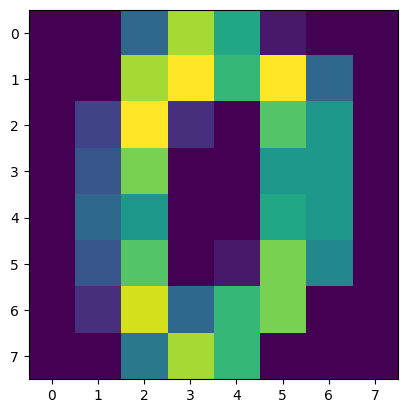

In [ ]:
from sklearn import datasets

digits = datasets.load_digits()

print(digits.target[0])

plt.imshow(digits.data[0].reshape((8,8)))

**5. [0.1 балла]** Примените к матрице `digits.data` сингулярное разложение.

In [ ]:
X = digits.data
U, S, VT = svd(X, full_matrices=False)
print("Размерности:")
print("U:", U.shape)
print("S:", S.shape)
print("VT:", VT.shape)

Размерности:
U: (1797, 64)
S: (64,)
VT: (64, 64)


**6. [0.65 балла]** Визуализируйте данные, спроецировав их на такую плоскость, чтобы координаты точек соответствовали первым двум новым признакам. Не забудьте покрасить точки, отвечающие различным цифрам, в разные цвета (если Вы любите красивые визуализации, разберитесь, как вместо точек рисовать маленькие цифры).

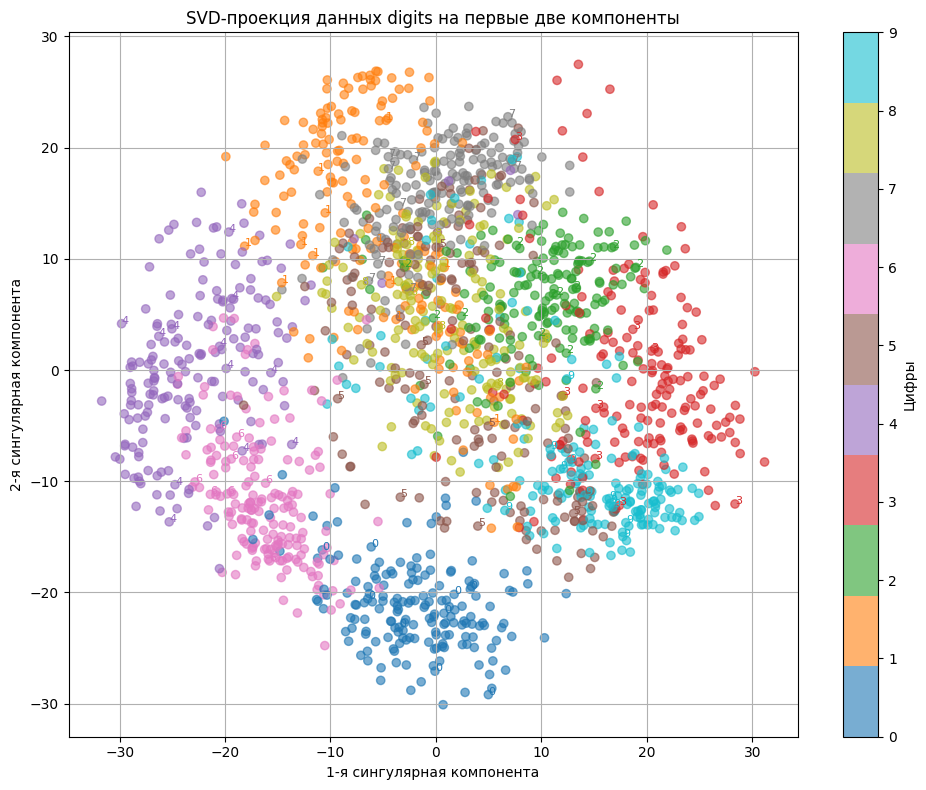

In [ ]:
import numpy as np
from sklearn.datasets import load_digits
from scipy.linalg import svd
import matplotlib.pyplot as plt

digits = load_digits()
X, y = digits.data, digits.target
X_centered = X - np.mean(X, axis=0)
U, S, VT = svd(X_centered, full_matrices=False)
X_2D = U[:, :2] * S[:2]

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_2D[:, 0], X_2D[:, 1], c=y, cmap='tab10', alpha=0.6)
plt.colorbar(scatter, label='Цифры')
for i in np.random.choice(len(X_2D), size=100, replace=False):
    plt.text(X_2D[i, 0], X_2D[i, 1], str(y[i]),
             color=plt.cm.tab10(y[i] / 10.),
             fontdict={'size': 8})

plt.xlabel("1-я сингулярная компонента")
plt.ylabel("2-я сингулярная компонента")
plt.title("SVD-проекция данных digits на первые две компоненты")
plt.grid(True)
plt.tight_layout()
plt.show()

### Задание 3. Когда SVD не сработает

**Disclaimer**

Цель этого задания — познакомить Вас не только с геометрическим смыслом сингулярного разложения, но и перекинуть очередной мостик между линейной алгеброй и анализом данных. К сожалению, на том берегу Вас встретят разные пока неизведанные понятия; мы постараемся по возможности дать какие-то определения, но, конечно, нет никакой возможности изложить на этих страницах полный курс теории вероятностей. Поэтому какие-то вещи останутся недосказанными или необоснованными; если Вам будет интересно, не стесняйтесь читать соответствующую литературу или хотя бы Википедию, а если нет, то мы надеемся, что хотя бы наглядное представление у Вас сформируется. В любом случае, нам хотелось бы, чтобы воспоминания об этом всколыхнулись в ваших головах, когда Вы будете это всё изучать в курсе по теории вероятностей.

Но начнём мы с того, что обсудим ситуацию, в которой SVD работает лучше всего: а именно, со случая, когда данные распределены нормально.

**Что такое плотность вероятности**

В дальнейшем Вам достаточно часто придётся сталкиваться со *случайными величинами*. Мы не будем сейчас пытаться строго определить, что это такое (для этого у вас будет целый курс по теории вероятностей), а остановимся только на одном его аспекте.

Если случайная величина $X$ принимает лишь конечное (или счётное) число значений $x_1,x_2,\ldots$, то чтобы задать её, достаточно описать, с какой вероятностью $X$ равна $x_i$:

$$p_i = P(X = x_i)$$

таким образом, чтобы $\sum_ip_i = 1$. Если же $X$ принимает значения на каком-либо отрезке или на всей числовой прямой, то так уже не получится: в этом случае вероятность того, что $X$ равна какому-то конкретному $x_0$, обычно равна нулю. Как правило, заменой вероятностей $p_i$ служит *функция плотности распределения* $p(x)$. Смысл её таков:

$$P(\alpha\leqslant X\leqslant\beta) = \int\limits_{\alpha}^{\beta}p(x)dx$$

(в левой части стоит вероятность того, что значение $X$ лежит на отрезке $[\alpha,\beta]$).

Таким образом, функция $p(x)$ действительно играет роль "плотности": вероятность попасть в отрезок одной и той же длины тем выше, чем больше значения $p(x)$ на нём.

**Нормальное распределение**

Одним из самых важных примеров непрерывных распределений является *нормальное распределение*. Его плотность имеет вид

$$p(x) = \frac1{\sqrt{2\pi\sigma^2}}e^{-\frac{(x - a)^2}{2\sigma^2}}$$

У него есть два параметра:

- $a$ - *математическое ожидание*, имеющее смысл среднего значения и для нормального распределения совпадающее с центром симметрии распределения;
- $\sigma^2$ - *дисперсия*: чем она меньше, тем в большей степени распределение сконцентрировано подле своего математического ожидания

Нормальное распределение с параметрами $a$ и $\sigma^2$ можно кратко обозначать $\mathcal{N}(a, \sigma^2)$.

Чтобы проиллюстрировать это, мы сгененерируем много точек из распределений $\mathcal{N}(2, 0.25)$, $\mathcal{N}(0, 1)$ и $\mathcal{N}(0, 4)$ и по ним в каждом из этих случаев построим аппроксимацию функции плотности распределения. Обратите внимание, что параметр $a$ в `numpy` называется `loc`, $\sigma$ (без квадрата!) — `scale`

In [ ]:
import numpy as np
from scipy.interpolate import UnivariateSpline
from matplotlib import pyplot as plt
%matplotlib inline
import seaborn as sns

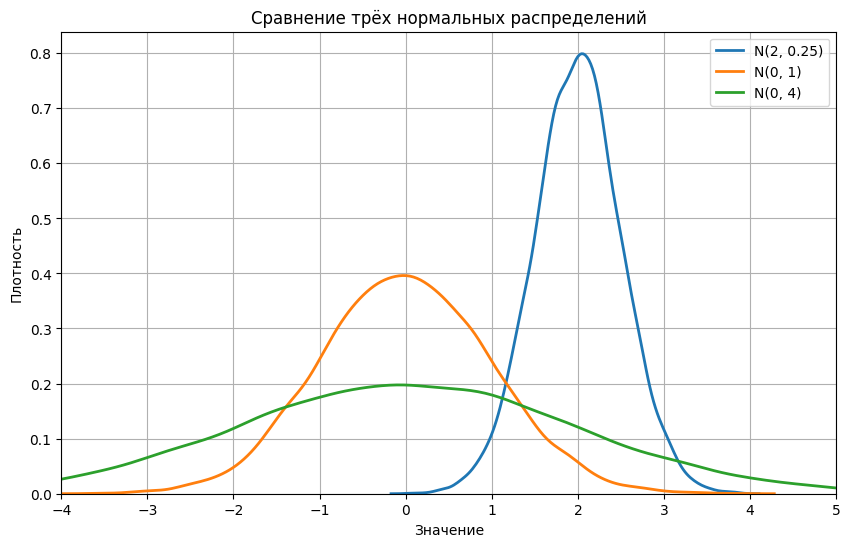

In [ ]:
N = 10000
plt.figure(figsize=(10, 6))
plt.xlim([-4, 5])

s = np.random.normal(loc=2, scale=0.5, size=N)
sns.kdeplot(s, linewidth=2, label='N(2, 0.25)', fill=False)
s = np.random.normal(loc=0, scale=1, size=N)
sns.kdeplot(s, linewidth=2, label='N(0, 1)', fill=False)
s = np.random.normal(loc=0, scale=2, size=N)
sns.kdeplot(s, linewidth=2, label='N(0, 4)', fill=False)

plt.legend()
plt.title('Сравнение трёх нормальных распределений')
plt.xlabel('Значение')
plt.ylabel('Плотность')
plt.grid(True)
plt.show()


**Функция плотности распределения в многомерном случае**

Если значения случайной величины $X$ — это многомерные векторы, функция плотности сохраняет примерно тот же смысл: если $\Omega\subseteq\mathbb{R}^n$, то

$$P(X\in\Omega) = \int\limits_{\Omega}p(x)dx$$

**Многомерное нормальное распределение**

Многомерное нормальное распределение определяется также двумя параметрами: *вектором средних* $a$ и положительно определённой *ковариационной матрицей* $\Sigma$; оно имеет плотность

$$p(x) = \frac1{(2\pi)^{n/2}|\Sigma|^{1/2}}e^{-\frac12(x - a)^T\Sigma^{-1}(x - a)}$$

где, напомним, $x$ — вектор из $\mathbb{R}^n$. Компоненты вектора $a$ — это математические ожидания отдельных координат $X$, а на диагонали матрицы $\Sigma$ стоят их *дисперсии* (настоящие, без кавычек). Вне диагонали стоят *ковариации* компонент $X$ (пока вам достаточно понимать, что если они равны нулю, то эти компоненты независимы$^1$).

---
$^1$ Точнее сказать, некоррелированны, однако для компонент многомерного нормального распределения независимость и некоррелированность равносильны (на самом деле редкое и удачное свойство!).

**Несколько фактов**

* Под (n-1)-мерным эллипсоидом будем понимать гиперповерхность в $\mathbb{R}^n$, такую что в некоторой прямоугольной декартовой системе координат её уравнение принимает вид $\sum_{i=1}^n \frac{x_i^2}{r_i^2} = 1$. Поверхности уровня $p(x) = c$ — это эллипсоиды.

*  Пользуясь теоремой о приведении квадратичной формы к главным осям, можно показать, что функция плотности многомерного нормального распределения представляется в виде произведения одномерных нормальных плотностей при переходе в новую систему координат.
$$p(x)=\frac1{(2\pi)^{n/2}|\Sigma|^{1/2}}e^{-\frac12(x - a)^T\Sigma^{-1}(x - a)}\:\underset{\text{новая система координат}}{\to}\: p(x)=p(x_1)\cdot ...\cdot p(x_n)$$

    В частности, это означает, что с помощью замены координат можно добиться того, чтобы отдельные компоненты были независимы (то есть матрица ковариации $\Sigma$ диагональна).

А мы тем временем продемонстрируем это на конкретном примере, сгенерировав много точек из двумерного нормального распределения с вектором средних $(-1,3)$ и ковариационной матрицей

$$\begin{pmatrix}
1 & \frac32\\
\frac32 & 5
\end{pmatrix}$$

и нарисовав приближённо линии уровня функции плотности.

/usr/local/lib/python3.11/dist-packages/seaborn/distributions.py:1176: UserWarning: The following kwargs were not used by contour: 'linewidth'
  cset = contour_func(


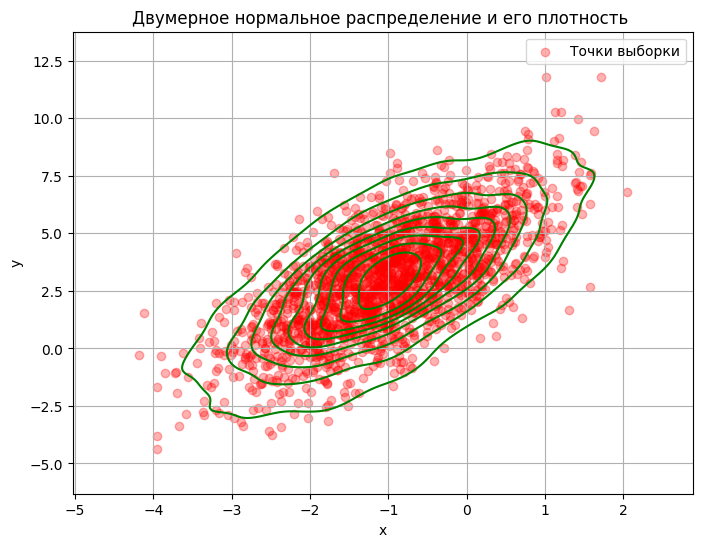

In [ ]:


N = 2000
mean = np.array([-1, 3])
cov = np.array([[1, 1.5], [1.5, 5]])
s = np.random.multivariate_normal(mean, cov, size=N)
plt.figure(figsize=(8, 6))
plt.scatter(s[:, 0], s[:, 1], color='red', alpha=0.3, label='Точки выборки')


sns.kdeplot(x=s[:, 0], y=s[:, 1], color='green', linewidth=2, fill=False)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Двумерное нормальное распределение и его плотность ")
plt.legend()
plt.grid(True)
plt.show()

Как видите, линии уровня весьма напоминают эллипсы (только напоминают, потому что точек у нас всё-таки конечное число).

**1. [0 баллов]** Сгенерируйте выборку из 1000 точек $x_1,\ldots,x_{1000}$ из нормального распределения с вектором средних $a = (0,0)$ и ковариационной матрицей

$$\Sigma = \begin{pmatrix}
1 & -2\\
-2 & 5
\end{pmatrix}.$$

/usr/local/lib/python3.11/dist-packages/seaborn/distributions.py:1176: UserWarning: The following kwargs were not used by contour: 'linewidth'
  cset = contour_func(


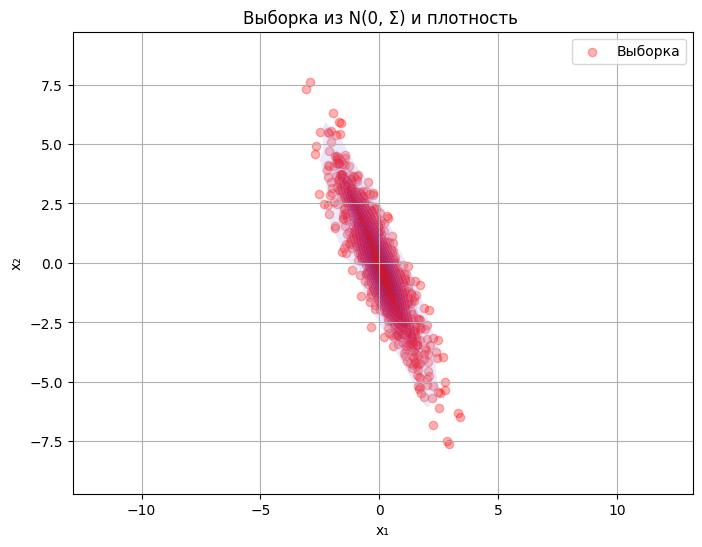

In [ ]:
mean = np.array([0, 0])
cov = np.array([[1, -2], [-2, 5]])

eigvals = np.linalg.eigvals(cov)

X = np.random.multivariate_normal(mean, cov, size=1000)


plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], alpha=0.3, color='red', label='Выборка')
sns.kdeplot(x=X[:, 0], y=X[:, 1], color='blue', linewidth=2, fill=True, alpha=0.3)
plt.xlabel("x₁")
plt.ylabel("x₂")
plt.title("Выборка из N(0, Σ) и плотность ")
plt.legend()
plt.grid(True)
plt.axis("equal")
plt.show()

**2. [0.25 балла]** Сделайте SVD-разложение $X = U\Sigma V^T$. Нарисуйте на плоскости все точки $x_i$ и направления новых признаков. Убедитесь, что направления новых признаков примерно совпадают с направлениями полуосей эллипса, образованного точками.

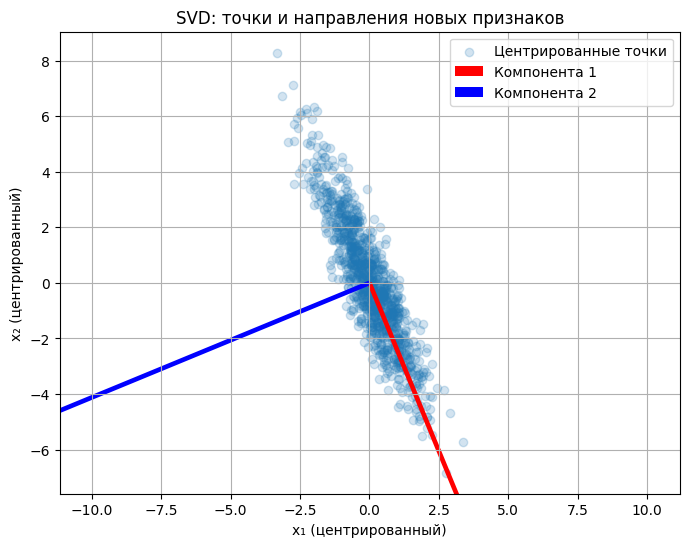

In [ ]:
mean = np.array([0, 0])
cov = np.array([[1, -2], [-2, 5]])
X = np.random.multivariate_normal(mean, cov, size=1000)


X_centered = X - np.mean(X, axis=0)


U, S, VT = np.linalg.svd(X_centered, full_matrices=False)

V = VT.T


plt.figure(figsize=(8, 6))
plt.scatter(X_centered[:, 0], X_centered[:, 1], alpha=0.2, label='Центрированные точки')


origin = np.mean(X, axis=0)
for i in range(2):
    vec = V[:, i] * S[i]
    plt.quiver(0, 0, vec[0], vec[1], angles='xy', scale_units='xy', scale=1,
               color=['red', 'blue'][i], label=f'Компонента {i+1}')

plt.axis('equal')
plt.grid(True)
plt.title("SVD: точки и направления новых признаков")
plt.xlabel("x₁ (центрированный)")
plt.ylabel("x₂ (центрированный)")
plt.legend()
plt.show()

**3. [0.5 балла]** Приведите к главным осям матрицу ковариации (это нужно сделать без привлечения `Python`) и убедитесь, что направления этих осей тоже примерно совпадают с наблюдаемыми направлениями полуосей эллипсоида.


Ищем $\lambda$ из характеристического уравнения:

$$
\det(\Sigma - \lambda I) = 0
\Rightarrow
\begin{vmatrix}
1 - \lambda & -2 \\
-2 & 5 - \lambda
\end{vmatrix}
= (1 - \lambda)(5 - \lambda) - 4 = 0.
$$



$$
(1 - \lambda)(5 - \lambda) - 4 = 5 - 6\lambda + \lambda^2 - 4 = \lambda^2 - 6\lambda + 1 = 0.
$$



$$
\lambda_{1,2} = \frac{6 \pm \sqrt{36 - 4}}{2} = \frac{6 \pm \sqrt{32}}{2} = \frac{6 \pm 4\sqrt{2}}{2} = 3 \pm 2\sqrt{2}.
$$

Собственные значения:

$$
\lambda_1 = 3 + 2\sqrt{2}, \quad \lambda_2 = 3 - 2\sqrt{2}.
$$


Для $\lambda_1 = 3 + 2\sqrt{2}$:

$$
(\Sigma - \lambda_1 I) v = 0.
$$


$$
\begin{pmatrix}
1 - \lambda_1 & -2 \\
-2 & 5 - \lambda_1
\end{pmatrix}
\cdot
\begin{pmatrix}
v_1 \\ v_2
\end{pmatrix}
= 0.
$$

Для конкретики подставим $\lambda_1 \approx 5.83$:

$$
\begin{pmatrix}
-4.83 & -2 \\
-2 & -0.83
\end{pmatrix}
\cdot
\begin{pmatrix}
v_1 \\ v_2
\end{pmatrix}
= 0.
$$


$$
-4.83 v_1 - 2 v_2 = 0 \quad \Rightarrow \quad v_2 \approx -2.415 v_1.
$$

Аналогично для $\lambda_2 \approx 0.17$:

$$
\begin{pmatrix}
0.83 & -2 \\
-2 & 4.83
\end{pmatrix}
\cdot
\begin{pmatrix}
v_1 \\ v_2
\end{pmatrix}
= 0,
\quad
\Rightarrow
v_2 \approx 0.415 v_1.
$$


Собственные векторы  приблизительно направлены вдоль:

 $v^{(1)} = (1, -2.415)$ — длинная ось,

 $v^{(2)} = (1, 0.415)$ — короткая ось.




╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ

Как Вы могли убедиться, SVD хорошо справляется со своей работой, когда данные распределены нормально, а в других случаях может давать совсем не такие информативные (или даже не адекватные) результаты.

**4. [0.25 балла]** Сгенерируйте двумерную выборку, представляющую собой два расположенных рядом (см. пример ниже) длинных и узких не пересекающихся эллипса с центрами в точках $(-1,0)$ и $(1,0)$ и с параллельными направлениями полуосей. Иными словами, постарайтесь как можно точнее воспроизвести картинку ниже.

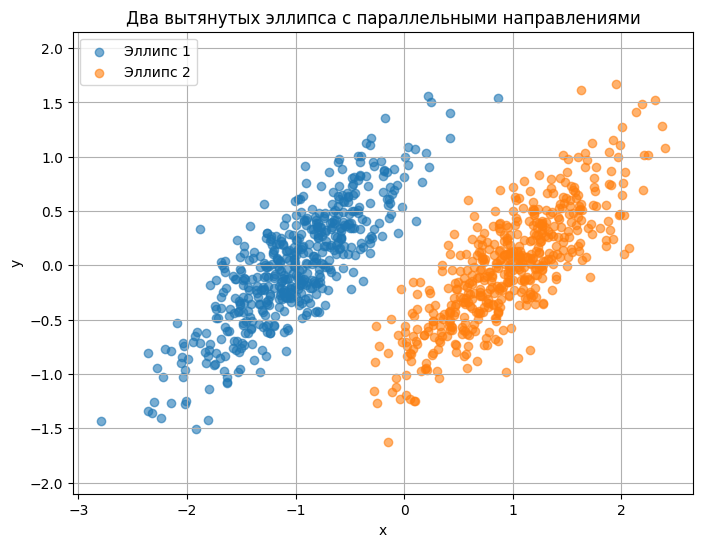

In [ ]:
np.random.seed(42)

cov_base = np.array([[3, 2.5],
                     [2.5, 3]])


n_samples = 500


mean1 = np.array([-1, 0])
ellipse1 = np.random.multivariate_normal(mean1, cov_base * 0.1, size=n_samples)


mean2 = np.array([1, 0])
ellipse2 = np.random.multivariate_normal(mean2, cov_base * 0.1, size=n_samples)


X = np.vstack([ellipse1, ellipse2])


plt.figure(figsize=(8, 6))
plt.scatter(ellipse1[:, 0], ellipse1[:, 1], alpha=0.6, label='Эллипс 1')
plt.scatter(ellipse2[:, 0], ellipse2[:, 1], alpha=0.6, label='Эллипс 2')
plt.title("Два вытянутых эллипса с параллельными направлениями")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

**5. [0.1 балла]** Сделайте SVD и нарисуйте направления новых признаков.

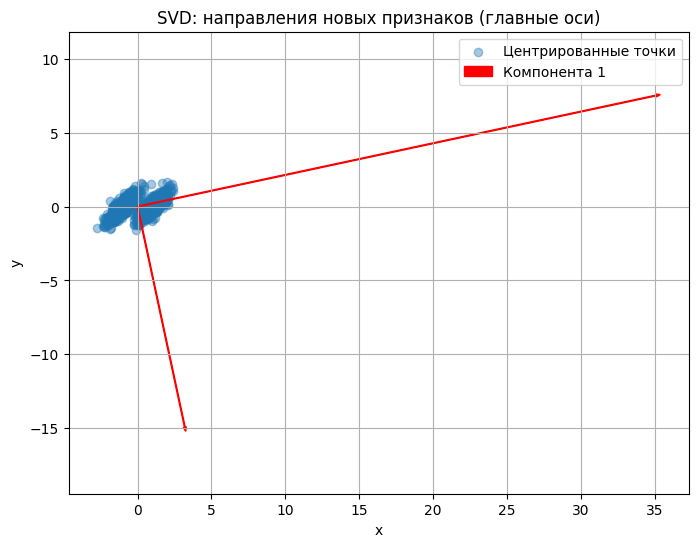

In [ ]:
np.random.seed(42)

cov_base = np.array([[3, 2.5],
                     [2.5, 3]])
n_samples = 500

mean1 = np.array([-1, 0])
mean2 = np.array([1, 0])

ellipse1 = np.random.multivariate_normal(mean1, cov_base * 0.1, size=n_samples)
ellipse2 = np.random.multivariate_normal(mean2, cov_base * 0.1, size=n_samples)

X = np.vstack([ellipse1, ellipse2])


X_centered = X - np.mean(X, axis=0)


U, S, VT = np.linalg.svd(X_centered, full_matrices=False)


components = VT.T


plt.figure(figsize=(8, 6))
plt.scatter(X_centered[:, 0], X_centered[:, 1], alpha=0.4, label='Центрированные точки')

origin = np.mean(X_centered, axis=0)

for i in range(2):
    vec = components[:, i] * S[i]
    plt.arrow(origin[0], origin[1], vec[0], vec[1],
              color='red', width=0.05, head_width=0.2,
              label=f'Компонента {i+1}' if i == 0 else None)

plt.title("SVD: направления новых признаков (главные оси)")
plt.xlabel("x")
plt.ylabel("y")
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.show()

Если бы мы решали задачу анализа данных, то скорее всего нас интересовал признак, который бы разделял два кластера (в данном случае два эллипса), то есть такая функция $f(x)$, для которой
$$f(x) < c,\ \mbox{если объект $x$ из первого класса}$$
$$f(x) > c,\ \mbox{если объект $x$ из второго класса}$$
для некоторого числа $c$.

**6. [0.25 балла]** Помогает ли какой-нибудь из двух предоставленных SVD признаков обнаружить эту структуру? Обязательно поясните свой ответ.

╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ

Первая сингулярная компонента помогает обнаружить структуру в данных и соответствует направлению наибольшей дисперсии.

 При выполнении SVD над центрированными данными $X$, мы получаем разложение:

  $$
  X = U \Sigma V^T
  $$

  где строки $V^T$ или столбцы задают направления новых признаков, упорядоченные по убыванию объясняемой дисперсии.

В случае двух вытянутых, почти коллинеарных эллипсов, основное различие между кластерами — это сдвиг вдоль общего вытянутого направления.

Первая сингулярная компонента $v_1$ ориентирована вдоль этого вытянутого направления и захватывает наибольшую дисперсию, то есть она эффективно отражает продольную структуру всей совокупности точек.

Вторая компонента $v_2$, наоборот, перпендикулярна первой и описывает лишь небольшие поперечные колебания. Она не помогает отличить две группы, так как различие между эллипсами вдоль этого направления минимально.




**7. [0 баллов]** Сгенерируйте выборку из 1000 точек $x_1,\ldots,x_{1000}$ из нормального распределения с вектором средних $a = (1,1)$ и ковариационной матрицей

$$\Sigma = \begin{pmatrix}
1 & 0\\
0 & 4
\end{pmatrix}.$$

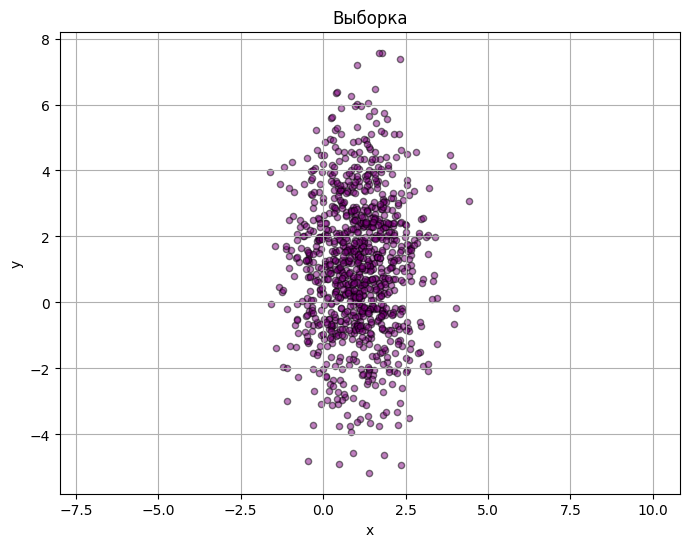

In [ ]:
mean = np.array([1, 1])
cov = np.array([[1, 0],
                [0, 4]])


n_samples = 1000
X = np.random.multivariate_normal(mean, cov, size=n_samples)


plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], alpha=0.5, color='purple', edgecolor='k', s=20)
plt.title('Выборка')
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
plt.grid(True)
plt.show()

**8. [0.2 балла]** Очевидно, что "интересными" для этого датасета направлениями будут направления полуосей эллипса-облака точек. Глядя только на матрицу $\Sigma$, определите, что это будут за направления? Поясните свой ответ.


$$
\Sigma = \begin{pmatrix}
1 & 0 \\
0 & 4
\end{pmatrix}
$$

Имеет следующие особенности:

Это диагональная матрица, значения на диагонали — это дисперсии по каждой из осей по оси $x$ дисперсия равна 1, по оси $y$ дисперсия равна 4.


Главные направления совпадают с осями координат $x$ и $y$, потому что ковариационная матрица не содержит смешанных членов.

Направление полуоси с меньшей дисперсией — ось $x$, так как дисперсия 1 меньше.

Направление полуоси с большей дисперсией — ось $y$, так как дисперсия 4 больше.




╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ

**9. [0.1 балла]** Сделайте SVD-разложение $X = U\Sigma V^T$. Нарисуйте все точки $x_i$ на плоскости и направления новых признаков.

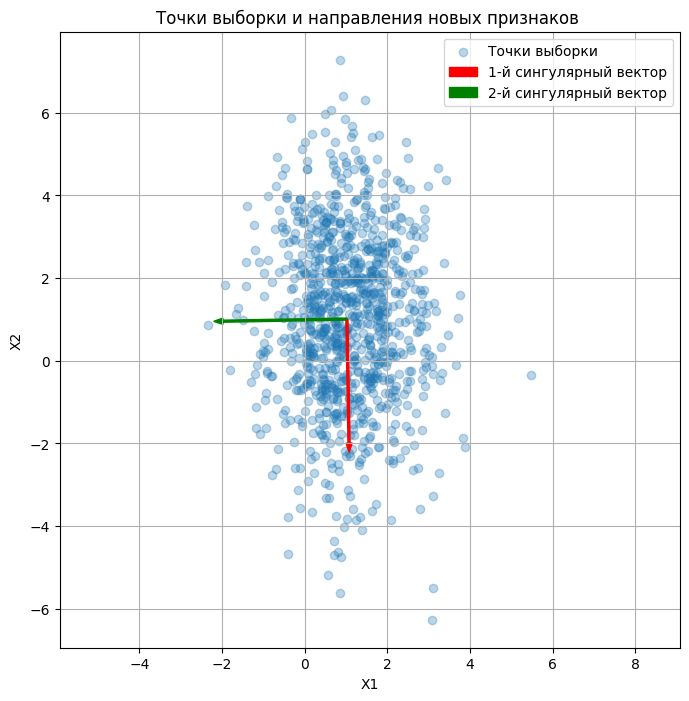

In [ ]:
mean = np.array([1, 1])
cov = np.array([[1, 0],
                [0, 4]])
n_samples = 1000

X = np.random.multivariate_normal(mean, cov, size=n_samples)


X_centered = X - np.mean(X, axis=0)
U, S, VT = np.linalg.svd(X_centered, full_matrices=False)


v1 = VT[0, :]
v2 = VT[1, :]


center = np.mean(X, axis=0)

plt.figure(figsize=(8, 8))
plt.scatter(X[:, 0], X[:, 1], alpha=0.3, label='Точки выборки')
scale = 3


plt.arrow(center[0], center[1], scale * v1[0], scale * v1[1], color='red', width=0.05, label='1-й сингулярный вектор')
plt.arrow(center[0], center[1], scale * v2[0], scale * v2[1], color='green', width=0.05, label='2-й сингулярный вектор')
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Точки выборки и направления новых признаков ')
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.show()

**10. [0.4 балла]** Сделайте вывод: в чём проблема и как можно её исправить?



Проблема, с которой мы столкнулись, связана с тем, что при работе с сингулярным разложением и визуализацией данных важно правильно центрировать выборку перед применением SVD. Если данные не центрированы, то первые сингулярные компоненты будут отражать смещение данных, а не направления максимальной дисперсии. Это исказит результаты и может привести к неверным выводам о структуре данных.


Исправить это можно вычитая среднее по каждому признаку перед применением SVD, проверяя масштабирование и отображение главных компонент соответствуют сингулярным значениям и используя диагонализацию ковариационной матрицы для интерпретации структуры данных.